In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
ds = pd.read_csv(r"C:\Users\Dell\Downloads\archive (1)\Salary_Data.csv")

In [ ]:
ds.info

<bound method DataFrame.info of     YearsExperience  Salary
0               1.1   39343
1               1.3   46205
2               1.5   37731
3               2.0   43525
4               2.2   39891
5               2.9   56642
6               3.0   60150
7               3.2   54445
8               3.2   64445
9               3.7   57189
10              3.9   63218
11              4.0   55794
12              4.0   56957
13              4.1   57081
14              4.5   61111
15              4.9   67938
16              5.1   66029
17              5.3   83088
18              5.9   81363
19              6.0   93940
20              6.8   91738
21              7.1   98273
22              7.9  101302
23              8.2  113812
24              8.7  109431
25              9.0  105582
26              9.5  116969
27              9.6  112635
28             10.3  122391
29             10.5  121872>

In [ ]:
x  = ds["YearsExperience"].values
y  = ds["Salary"].values


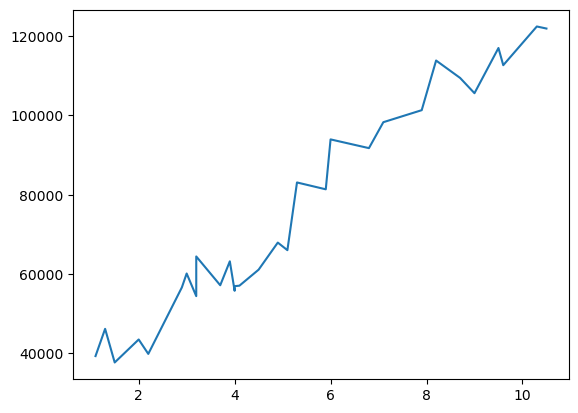

In [ ]:
plt.plot(x,y)

In [ ]:
X = np.array(x)
Y = np.array(y)


In [ ]:
def mean(X):
    return np.sum(X)/len(X)

In [ ]:
def variance(X):
    mean_val = mean(X)
    return np.sum((X-mean_val)**2)/len(X)

In [ ]:
def norm(X):
    mean_val = mean(X)
    var_val = variance(X)
    return (X-mean_val)/np.sqrt(var_val)

In [ ]:
X_norm = norm(X)
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

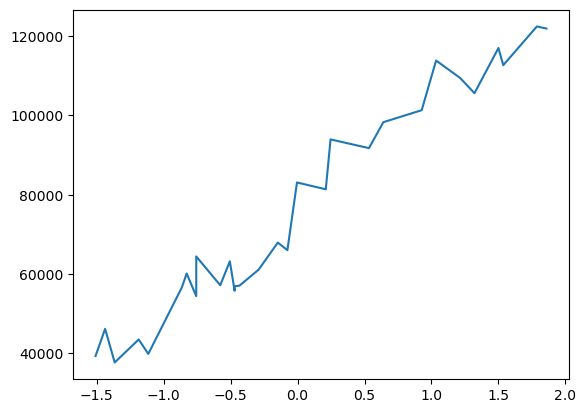

In [ ]:
plt.plot(X_norm , Y)

In [ ]:
import random

In [ ]:
class SimpleLR:
    def __init__(self , lr=0.1 , max_iter=2000 , threshold = 1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)

    def predict(self, X):
        return (self.weight)*X + self.bias

    def fit(self, X ,Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y-y_pred
        prev_loss = (1/(2*n))*np.sum(errors**2)
        loss_history.append(prev_loss)

        for i in range(self.max_iter):
            w_grad = (1/n)*np.sum(errors*X)
            b_grad = (1/n)*np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n))*np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            if(i%10 == 0):
                loss_history.append(curr_loss)
        return loss_history


    def plot(self , X , Y):
        y_pred = self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)


In [ ]:
#NOW INTIALIZING MODEL OBJECT

In [ ]:
model = SimpleLR()

In [ ]:
loss_history = model.fit(X_norm , Y)

In [ ]:
loss_history

[np.float64(3251510614.7811356),
 np.float64(2636694338.386336),
 np.float64(334295043.85191655),
 np.float64(54377040.09073512),
 np.float64(20345545.63378024),
 np.float64(16208110.386986187),
 np.float64(15705094.85109586),
 np.float64(15643939.905035231),
 np.float64(15636504.891281513),
 np.float64(15635600.967182498),
 np.float64(15635491.071114542),
 np.float64(15635477.710318241),
 np.float64(15635476.085957333),
 np.float64(15635475.888472961),
 np.float64(15635475.864463475),
 np.float64(15635475.861544482),
 np.float64(15635475.861189604),
 np.float64(15635475.861146454)]

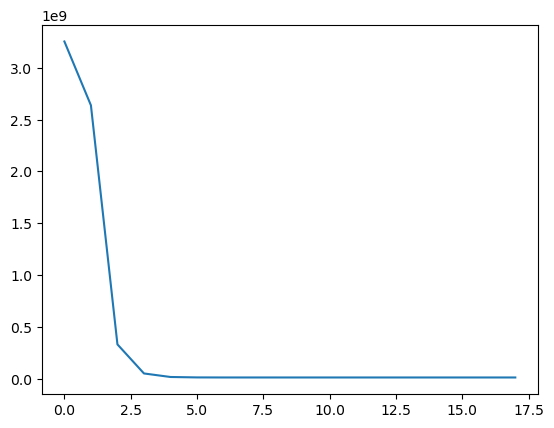

In [ ]:
plt.plot(loss_history)

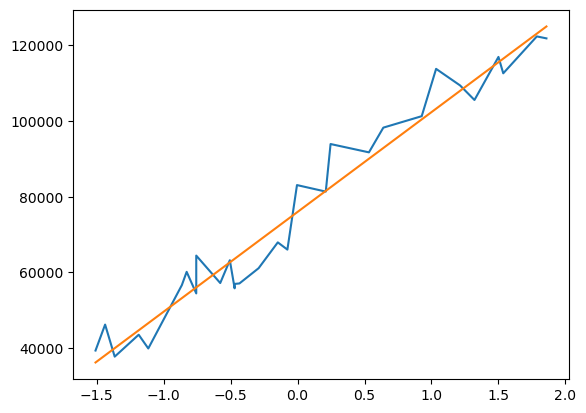

In [ ]:
model.plot(X_norm , Y)

In [ ]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
X_norm = X_norm.reshape(-1,1)
model.fit(X_norm , Y)

LinearRegression()

In [ ]:
model.score(X_norm , Y)


0.9569566641435086